# Using Sentinel-1 and -2 data to build a land use classification model/ Ứng dụng ảnh viễn thám Sentinel 1 và Sentinel-2  trong phân loại hiện trạng sử dụng đất (thí điểm tại xã Thuận Hòa, huyện Châu Thành, tỉnh Sóc Trăng)

## Overview/Tổng quan
This notebook will take you through a workflow for processing Sentinel-1 and -2 data./ Phần này hướng dẫn quy trình xử lý ảnh Sentinel 1 và 2

## Required datafiles/Các dữ liệu yêu cầu
This notebook requires three files:/ Trong phần này, các dữ liệu được yêu cầu bao gồm:
- A shapefile that contains land use information/Dữ liệu điểm khảo sát thực địa: `ST_training data_updated_1130points.shp`
- A raster sentinel-1 vv file (single VV polarisation)/Dữ liệu ảnh Sentinel 1 phân cực VV định dạng raster: `vv-0922_0923-full_ST.tif`
- A raster sentinel-1 vh file (single VH polarisation) )/Dữ liệu ảnh Sentinel 1 phân cực VH định dạng raster: `vh-0922_0923-full_ST.tif`
[Sentinel-1](https://sentinels.copernicus.eu/web/sentinel/user-guides/sentinel-1-sar/product-overview/polarimetry) can collect several different images from the same series of pulses by using its antenna to receive specific polarisations simultaneously. Sentinel-1 is a phase-preserving dual polarisation SAR system. It can transmit a signal in either horizontal (H) or vertical (V) polarisation, and then receive in both H and V polarisations./ Sentinel 1 là vệ tinh RADAR khẩu độ tổng hợp có thể thu thập các ảnh khác nhau từ một chuỗi ảnh bằng việc sử dụng ăng ten thu nhận đồng thời các phân cực (VH, VV). Sentinel 1 là ảnh SAR với phân cực kép, có thể truyền tín hiệu theo phân cực ngang (H), phân cực dọc (V), sau đó nhận tín hiệu ở cả phân cực H và V.

## Setting up your notebook/Cài đặt notebook của bạn

We will now setup your notebook so that you have all of the required python modules to query, analyse and plot the data./Chúng tôi sẽ thiết lập Notebook để người dùng có tất cả các mô-đun cần thiết cho truy vấn, phân tích và vẽ biểu đồ dữ liệu

### Import modules/Nhập các mô-đun

In [1]:
# Basic plots
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = [12, 8]

# Common imports and settings
import os, sys
os.environ['USE_PYGEOS'] = '0'
from IPython.display import Markdown
import pandas as pd
pd.set_option("display.max_rows", None)
import xarray as xr

# Datacube
# import datacube
# from datacube.utils.rio import configure_s3_access
# from datacube.utils import masking
# from datacube.utils.cog import write_cog
# https://github.com/GeoscienceAustralia/dea-notebooks/tree/develop/Tools
# from dea_tools.plotting import display_map, rgb
# from dea_tools.datahandling import mostcommon_crs

# EASI defaults
# easinotebooksrepo = '/home/jovyan/easi-notebooks'
# if easinotebooksrepo not in sys.path: sys.path.append(easinotebooksrepo)
# from easi_tools import EasiDefaults, xarray_object_size, notebook_utils, unset_cachingproxy
# from easi_tools.load_s2l2a import load_s2l2a_with_offset

# Data tools
import numpy as np
from datetime import datetime

# Datacube
# from datacube.utils import masking  # https://github.com/opendatacube/datacube-core/blob/develop/datacube/utils/masking.py
from odc.algo import enum_to_bool   # https://github.com/opendatacube/odc-algo/blob/main/odc/algo/_masking.py
# from odc.algo import xr_reproject   # https://github.com/opendatacube/odc-algo/blob/main/odc/algo/_warp.py
# from datacube.utils.geometry import GeoBox, box  # https://github.com/opendatacube/datacube-core/blob/develop/datacube/utils/geometry/_base.py

# Holoviews, Datashader and Bokeh
import hvplot.pandas
import hvplot.xarray
import holoviews as hv
import panel as pn
import colorcet as cc
import cartopy.crs as ccrs
from datashader import reductions
from holoviews import opts
from utils import load_data_geo
import rasterio
import os
import rioxarray
# import geoviews as gv
# from holoviews.operation.datashader import rasterize
hv.extension('bokeh', logo=False)

from deafrica_tools.bandindices import calculate_indices
import numpy as np
from cuml.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

from sklearn.pipeline import Pipeline
from cuml.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.model_selection import GridSearchCV, learning_curve
import seaborn as sns
import joblib
# Planetary Computer STAC imports
import pystac_client
import planetary_computer
import odc.stac


### Setting up dask/Thiết lập dask
We will now set up a dask cluster. The below code sets up a 'dask gateway' which allows processing of up to 10 worker nodes (cores) for fast parallel processing./Chúng ta sẽ thiết lập cụm dask. Đoạn code dưới đây cho phép thiết lập một “cổng dask” với việc xử lý tối đa 10 lõi chạy song song.
The below code usually takes about 3 minutes to run while dask starts up a new cluster. Once the cluser has initiliased, you can click Launch dashboard in JupyterLab to monitor the cluster acitivity./Code này mất 3 phút để chạy khi dask khởi tạo một cụm mới. Khởi chạy bảng điều khiển trong JupyterLan để theo dõi hoạt động của cụm vừa được tạo.

In [2]:
# Dask gateway
from dask.distributed import Client, LocalCluster
import os
os.environ['GDAL_HTTP_MAX_RETRY'] = '5'
os.environ['GDAL_HTTP_RETRY_DELAY'] = '3'
os.environ['GDAL_HTTP_TIMEOUT'] = '60'
cluster = LocalCluster(n_workers=4, threads_per_worker=4)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 46.94 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41957,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 16
Started: Just now,Total memory: 46.94 GiB
Comm: tcp://127.0.0.1:42337,Total threads: 4
Dashboard: http://127.0.0.1:33405/status,Memory: 11.74 GiB
Nanny: tcp://127.0.0.1:40355,


### Loading the datacube/Tải khối dữ liệu
Next we load the datacube object. This datacube is what we will use to read the satellite data into memory. We must also configure s3 access to the Sentinel-2 data which is available in the cloud./Datacube chính là khối dữ liệu chứa các ảnh viễn thám. Trong đó, chúng ta cần cấu hình quyền truy cập vào dữ liệu Sentinel 2 có sẵn trên đám mây.

In [3]:
# Initialise Planetary Computer STAC client
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)


### Defining a search query/Truy vấn dữ liệu
We now need to query the sentinel-2 cloud database on EASI. To extract data we define a query dictionary that contains search criteria such as spatial and temporal limits./ Bây giờ chúng ta cần truy vấn cơ sở dữ liệu đám mây Sentinel-2 trên EASI. Để trích xuất dữ liệu, xác định các tiêu chí, điều kiện truy vấn như giới hạn không gian (khu vực nghiên cứu), thời gian (giai đoạn nghiên cứu)

In [4]:
# MODE CONFIGURATION: TEST MODE OR PRODUCTION RUN
# CHẾ ĐỘ CHẠY: TEST (NHANH) HOẶC HUẤN LUYỆN CHÍNH THỨC
TEST_MODE = True  # Đổi thành False nếu muốn chạy chính thức (full thời gian, full tham số)

if TEST_MODE:
    min_date = '2022-09-01'
    max_date = '2022-10-01'
    cache_file = 'data_cache_test.npz'
else:
    min_date = '2022-01-01'
    max_date = '2023-01-01'
    cache_file = 'data_cache_prod.npz'

# Specify a spatail region to search using latitude/longitude cooridinates
min_longitude, max_longitude = (105.5, 106.4)
min_latitude, max_latitude = (9.2, 10.0)

# Construct STAC search query
bbox = [min_longitude, min_latitude, max_longitude, max_latitude]
datetime = f"{min_date}/{max_date}"

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=datetime,
)
items = list(search.items())
print(f"Found {len(items)} STAC items")

Found 68 STAC items


### Most common CRS/Hệ quy chiếu, phép chiếu phổ biến
We can select the most appropriate CRS projection using the notebook_utils helper function. This function takes into account the data product and spatial location and determines the most common CRS for that region. It generally takes 1-2 seconds to find the most common CRS./ Chúng ta có thể chọn phép chiếu CRS phù hợp nhất ứng dụng hàm trợ giúp notebook_utils. Hàm này xem xét cả về dữ liệu và vị trí không gian, xác định CRS phổ biến nhất cho khu vực quan sát. Thông thường sẽ mất 1-2 giây để tìm CRS phổ biến nhất.

In [5]:
# Most common CRS
# In Vietnam region, UTM zone 48N is typical. STAC items from Planetary Computer use EPSG:32648
native_crs = "EPSG:32648"
print(f'Most common native CRS: {native_crs}')


Most common native CRS: EPSG:32648


### Target xarray parameters/Các thông số xarray mục tiêu
Next we can define which target parameters we would like to load into our xarray object. In general we need to:/ Tiếp theo, chúng ta xác định tham số nào cần tải về cho đối tượng xrray. Cụ thể:
- Select a set of measurements to load/Chọn một tập hợp các kênh ảnh cần tải 
- Define an appropriate output CRS and resolution/Xác định hệ quy chiếu và độ phân giải ảnh
- Decide on how we group the data (usually we groupby input scenes on the same day to a single time layer)./Xác định các nhóm dữ liệu (thông thường các dữ liệu cùng ngày sẽ được nhóm vào cùng 1 lớp dữ liệu thời gian)
- Select a reasonable Dask chunk size (this should be adjusted depending on the spatial and resolution parameters you choose/Chọn kích thước Chun dask phù hợp (nó được điều chỉnh phụ thuộc vào thông số thời gian và không gian)

In [6]:
# Specify the spectral band measurements we want to use for a classification algorithm
measurements = ['B02', 'B03', 'B04', 'B08', 'SCL']

load_params = {
    'bands': measurements,
    'crs': native_crs,
    'resolution': 10,
    'groupby': 'solar_day',
    'chunks': {'x': 2048, 'y': 2048},
    'bbox': bbox,
    'patch_url': planetary_computer.sign,
}


### Loading the data/Tải dữ liệu
We are now read to load the data into our datacube object. For sentinel-2 data we can use the **load_s2l2a_with_offset** helper function so that the sentinel-2 scale and offset coefficients are applied correctly. More information on this issue is discussed here./ Chúng ta đang đọc để tải dữ liệu vào datacube của bản thân. Đối với dữ liệu Sentinel-2, chúng ta có thể sử dụng hàm trợ giúp **Load_s2l2a_with_offset** để thang đo Sentinel-2 và các hệ số bù được áp dụng chính xác. Thông tin thêm về vấn đề này được thảo luận ở đây.

In [7]:
# The replacement odc.stac.load function for this product
data = odc.stac.load(
    items,
    **load_params
)

# Rename bands to match original code
data = data.rename({'B02': 'blue', 'B03': 'green', 'B04': 'red', 'B08': 'nir', 'SCL': 'scl'})

# Planetary computer Sentinel-2 data is already scaled, but might need offset depending on processing baseline. 
# Usually odc.stac loads it as uint16. To match what datacube does (convert to float and apply scale/offset):
# Planetary Computer Sentinel-2 L2A has scale=0.0001, offset=0
data['blue'] = data['blue'].astype('float32') * 0.0001
data['green'] = data['green'].astype('float32') * 0.0001
data['red'] = data['red'].astype('float32') * 0.0001
data['nir'] = data['nir'].astype('float32') * 0.0001

display(data)


<xarray.Dataset> Size: 21GB
Dimensions:      (y: 8874, x: 9902, time: 12)
Coordinates:
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
  * time         (time) datetime64[ns] 96B 2022-09-02T03:15:31.024000 ... 202...
Data variables:
    blue         (time, y, x) float32 4GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    green        (time, y, x) float32 4GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    red          (time, y, x) float32 4GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    nir          (time, y, x) float32 4GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    scl          (time, y, x) float32 4GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>

### Masking



In [8]:
# The "SCL" band contains quality flags and information.
flag_name = 'scl'

# Define good pixel flags for Sentinel-2 SCL manually since masking.describe_variable_flags was from datacube
# 2: Dark area pixels, 4: Vegetation, 5: Not vegetated, 6: Water
good_pixel_flags = [2, 4, 5, 6]

# Create a "data quality" Mask layer
# 1 = good data, 0 = "bad" data
good_pixel_mask = data[flag_name].isin(good_pixel_flags)


In [9]:
if 'cache_file' in globals() and os.path.exists(cache_file):
    print("Cache found! Skipping layer names extraction.")
    data_layer_names = []
else:
    data_layer_names = [x for x in data.data_vars if x != 'scl']

Cache found! Skipping layer names extraction.


In [10]:
data_layer_names

[]

In [11]:
if 'cache_file' in globals() and os.path.exists(cache_file):
    print("Cache found! Skipping mask application.")
    result = None
else:
    from dask.distributed import progress
    # Apply good pixel mask to blue, green, red and nir.
    result = data[data_layer_names].where(good_pixel_mask)

Cache found! Skipping mask application.


### Note on Dask Progress Monitoring / Lưu ý về theo dõi tiến trình Dask

**Important:** If you encounter `CommClosedError` or connection issues with Dask, the computations are still running in the background. You can:
1. Wait for the computation to complete
2. Check the Dask dashboard for progress
3. Use `compute()` directly which will wait for results

**Quan trọng:** Nếu gặp lỗi `CommClosedError` hoặc vấn đề kết nối với Dask, các tính toán vẫn đang chạy ở chế độ nền. Bạn có thể:
1. Đợi tính toán hoàn thành
2. Kiểm tra bảng điều khiển Dask để xem tiến trình
3. Sử dụng `compute()` trực tiếp sẽ đợi kết quả

In [12]:
# Optional: Check Dask cluster status / Kiểm tra trạng thái cluster Dask (tùy chọn)
try:
    print(f"Cluster status: {client.status}")
    print(f"Number of workers: {len(client.scheduler_info()['workers'])}")
    print("Dask cluster is running properly / Cluster Dask đang hoạt động bình thường")
except Exception as e:
    print(f"Warning: Cannot connect to Dask cluster - {e}")
    print("Cảnh báo: Không thể kết nối đến cluster Dask")

Cluster status: running
Number of workers: 4
Dask cluster is running properly / Cluster Dask đang hoạt động bình thường


In [13]:
if 'cache_file' in globals() and os.path.exists(cache_file):
    print("Cache found! Skipping Dask wait.")
else:
    print("Using persist() - data is being computed in background")
    from distributed import wait
    wait(result)  # Wait for computation without progress bar
    print("Computation completed successfully!")

Cache found! Skipping Dask wait.


In [14]:
if 'cache_file' in globals() and os.path.exists(cache_file):
    print("Cache found! Skipping index calculation.")
    ndvi = None
    average_ndvi = None
else:
    ds1 = calculate_indices(result, index='NDVI', satellite_mission='s2')
    ndvi = ds1["NDVI"]
    average_ndvi = ndvi.resample(time='1M').mean()  ## tính mean cho từng tháng -> time = 12

Cache found! Skipping index calculation.


In [15]:
if 'cache_file' in globals() and os.path.exists(cache_file):
    print("Cache found! Skipping NDVI wait.")
else:
    print("Using persist() - NDVI data is being computed in background")
    from distributed import wait
    # wait(average_ndvi)  # Wait for computation without progress bar
    print("NDVI computation completed successfully!")

Cache found! Skipping NDVI wait.


In [16]:
if 'cache_file' in globals() and os.path.exists(cache_file):
    print("Cache found! Skipping NDVI compute.")
else:
    average_ndvi = average_ndvi.compute()

Cache found! Skipping NDVI compute.


In [17]:
# plt.imshow(average_ndvi.isel(time=0)[1000:1100, 1000:1100].compute())

In [18]:
if 'cache_file' in globals() and os.path.exists(cache_file):
    print("Cache found! Skipping bfill/ffill.")
    filled_ds = None
else:
    filled_ds = average_ndvi.bfill(dim='time')
    filled_ds = filled_ds.ffill(dim='time')

Cache found! Skipping bfill/ffill.


In [19]:
# # plt.imshow(filled_ds.isel(time=0))

In [20]:
train_path = "train/ST_training data_updated_1130points.shp"  # đường dẫn shp file train
train = load_data_geo(train_path)
train.head()

,No,X,Y,LU2022,Hientrang,HT_code,geometry
0,1.0,603860.819,1081162.862,Pomelo,CLN,5,POINT (603860.819 1081162.862)
1,2.0,601306.410,1082782.940,Pomelo,CLN,5,POINT (601306.41 1082782.94)
2,3.0,601084.510,1081351.870,Pomelo,CLN,5,POINT (601084.51 1081351.87)
3,4.0,602193.760,1079205.220,Pomelo,CLN,5,POINT (602193.76 1079205.22)
4,5.0,602459.000,1080946.000,Pomelo,CLN,5,POINT (602459 1080946)


## Downloading Sentinel-1 data/Tải ảnh Sentinel 1
The sentinel-1 data files are available via an s3 bucket. To download the files locally we will use the aws client. First, check the files are available on the s3 bucket:/ Các dữ liệu ảnh Sentinel-1 có sẵn thông qua S3 (dịch vụ lưu trữ và truy xuất của Amazon). Để tải xuống các tệp cục bộ, chúng tôi sẽ sử dụng ứng dụng khách của aws. Trước tiên, kiểm tra các tệp có sẵn trên s3:

In [21]:

# The downloads take 2-3 minutes to complete.
import os
if not os.path.exists("vh-0922_0923-full_ST.tif"):
    !aws s3 cp s3://easi-asia-dc-data/staging/ctu/sentinel-1/vh-0922_0923-full_ST.tif vh-0922_0923-full_ST.tif
if not os.path.exists("vv-0922_0923-full_ST.tif"):
    !aws s3 cp s3://easi-asia-dc-data/staging/ctu/sentinel-1/vv-0922_0923-full_ST.tif vv-0922_0923-full_ST.tif

/bin/bash: line 1: aws: command not found
/bin/bash: line 1: aws: command not found


### Load Sentinel-1 data/ Tải dữ liệu Senttinel từ S3

In [22]:
if 'cache_file' in globals() and os.path.exists(cache_file):
    print("Cache found! Skipping Sentinel-1 loading.")
    dsvh = None
    dsvv = None
else:
    import rioxarray
    # Load Sentinel-1 data
    dsvh = rioxarray.open_rasterio("vh-0922_0923-full_ST.tif")
    dsvv = rioxarray.open_rasterio("vv-0922_0923-full_ST.tif")

Cache found! Skipping Sentinel-1 loading.


### Label the training data/ Thống nhất nhãn dữ liệu thực địa

In [23]:
import os
import numpy as np

# cache_file is set globally in Cell 11
if os.path.exists(cache_file):
    print("Cache found! Loading data from disk...")
    cache = np.load(cache_file)
    x_new = cache['x_new'].tolist()
    lb_new = cache['lb_new'].tolist()
    loaded_datasets = {} # Dummy to prevent errors later
else:
    
    import xarray as xr
    
    # Vectorized point extraction (much faster than loop)
    x_coords = xr.DataArray(train.geometry.x.values, dims="point")
    y_coords = xr.DataArray(train.geometry.y.values, dims="point")
    
    print("Extracting NDVI data...")
    ndvi_points = filled_ds.sel(x=x_coords, y=y_coords, method='nearest').compute()
    print("Extracting VH data...")
    vh_points = dsvh.sel(x=x_coords, y=y_coords, method='nearest').compute()
    print("Extracting VV data...")
    vv_points = dsvv.sel(x=x_coords, y=y_coords, method='nearest').compute()
    
    loaded_datasets = {}
    for idx, point in train.iterrows():
        key = f"point_{idx + 1}"
        try:
            ndvi_data = ndvi_points.isel(point=idx).values
            vh_data = vh_points.isel(point=idx).values
            vv_data = vv_points.isel(point=idx).values
            
            loaded_datasets[key] = {
                "data": np.concatenate((ndvi_data, vh_data, vv_data)),
                "label": point.HT_code
            }
        except Exception as e:
            print(e)
    


Cache found! Loading data from disk...


In [24]:
label_mapping = {
    "Lua tom": "0",
    "Lua": "1",
    "CHN": "2",
    "CLN": "3",
    "TS": "4",
    "Song": "5",
    "Dat xay dung": "6",
    "Rung": "7"
}
label_encoder = LabelEncoder()

# Fit and transform the labels
labels = train.Hientrang.values
numeric_labels = label_encoder.fit_transform([label_mapping[label] for label in labels])

In [25]:
if not os.path.exists(cache_file):
    X = []
    x_new = []
    lb_new = []
    for k, v in loaded_datasets.items():
        X.append(v)
    for i in range(len(X)):
        if X[i] is not None:
            x_new.append(X[i]["data"])
            lb_new.append(numeric_labels[i])
            
    print("Saving extracted data to cache...")
    np.savez(cache_file, x_new=x_new, lb_new=lb_new)
else:
    print("Data loaded from cache successfully. Ready for training!")


Data loaded from cache successfully. Ready for training!


### Split training data / Chia tập dữ liệu huấn luyện

In [26]:
X_train, X_temp, y_train, y_temp= train_test_split(x_new, lb_new, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

import numpy as np
X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.int32)
X_val = np.array(X_val, dtype=np.float32)
y_val = np.array(y_val, dtype=np.int32)
X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test, dtype=np.int32)


### Model training pipeline/ huấn luyện mô hình và đánh giá trên tập validate

In [27]:

# Takes 1-2 minutes to complete

# Tạo RandomForestClassifier mặc định để sử dụng làm mô hình ban đầu trong pipeline
base_model = RandomForestClassifier(random_state=42)

# Tạo pipeline
pipeline = Pipeline([
    # ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('classifier', base_model),
])
# Thiết lập các tham số bạn muốn tối ưu hóa
param_grid = {
    'classifier__n_estimators': [100, 300, 500, 700, 1000],
    'classifier__max_depth': [6, 8, 10, 15, 20],
    'classifier__split_criterion': ['gini', 'entropy'],
}

# Sử dụng GridSearchCV để tìm bộ tham số tốt nhất
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# In ra bộ tham số tốt nhất
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Dự đoán trên tập kiểm tra
y_pred = grid_search.predict(X_val)

# Đánh giá kết quả
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {round(accuracy, 2)*100} %")

Best Parameters: {'classifier__max_depth': 6, 'classifier__n_estimators': 100, 'classifier__split_criterion': 'gini'}
Accuracy: 35.0 %


### Accuracy on the test data/ Độ chính xác trên tập dữ liệu kiểm tra

In [28]:
## check accuracy score

y_pred_test = grid_search.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Accuracy for test data {round(test_accuracy, 2)*100} %")

Accuracy for test data 34.0 %


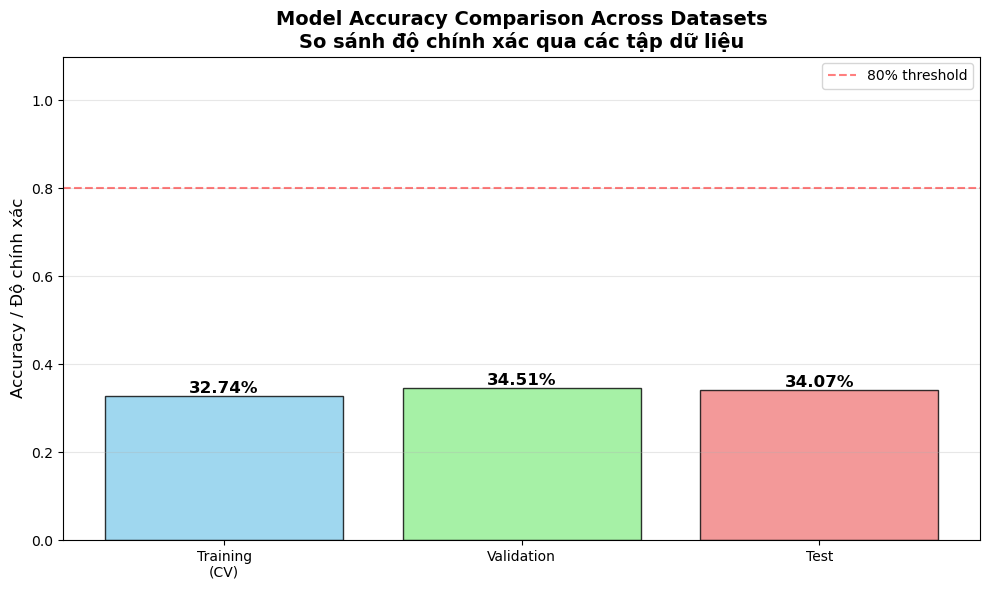


MODEL PERFORMANCE SUMMARY / TỔNG KẾT HIỆU SUẤT MÔ HÌNH
Cross-Validation Accuracy: 32.74%
Validation Accuracy:       34.51%
Test Accuracy:             34.07%

Best Parameters / Tham số tốt nhất:
  classifier__max_depth: 6
  classifier__n_estimators: 100
  classifier__split_criterion: gini


In [29]:
# Vẽ biểu đồ tổng kết so sánh accuracy giữa các tập dữ liệu
datasets = ['Training\n(CV)', 'Validation', 'Test']
accuracies = [grid_search.best_score_, accuracy, test_accuracy]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(datasets, accuracies, color=['skyblue', 'lightgreen', 'lightcoral'], alpha=0.8, edgecolor='black')

# Thêm giá trị lên từng cột
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc*100:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy / Độ chính xác', fontsize=12)
ax.set_title('Model Accuracy Comparison Across Datasets\nSo sánh độ chính xác qua các tập dữ liệu', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='80% threshold')
ax.legend()

plt.tight_layout()
plt.show()

# In tổng kết
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY / TỔNG KẾT HIỆU SUẤT MÔ HÌNH")
print("="*60)
print(f"Cross-Validation Accuracy: {grid_search.best_score_*100:.2f}%")
print(f"Validation Accuracy:       {accuracy*100:.2f}%")
print(f"Test Accuracy:             {test_accuracy*100:.2f}%")
print(f"\nBest Parameters / Tham số tốt nhất:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print("="*60)

#### 6. Model Performance Summary / Tổng kết hiệu suất mô hình

/home/x79/miniconda3/envs/env_01/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/x79/miniconda3/envs/env_01/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


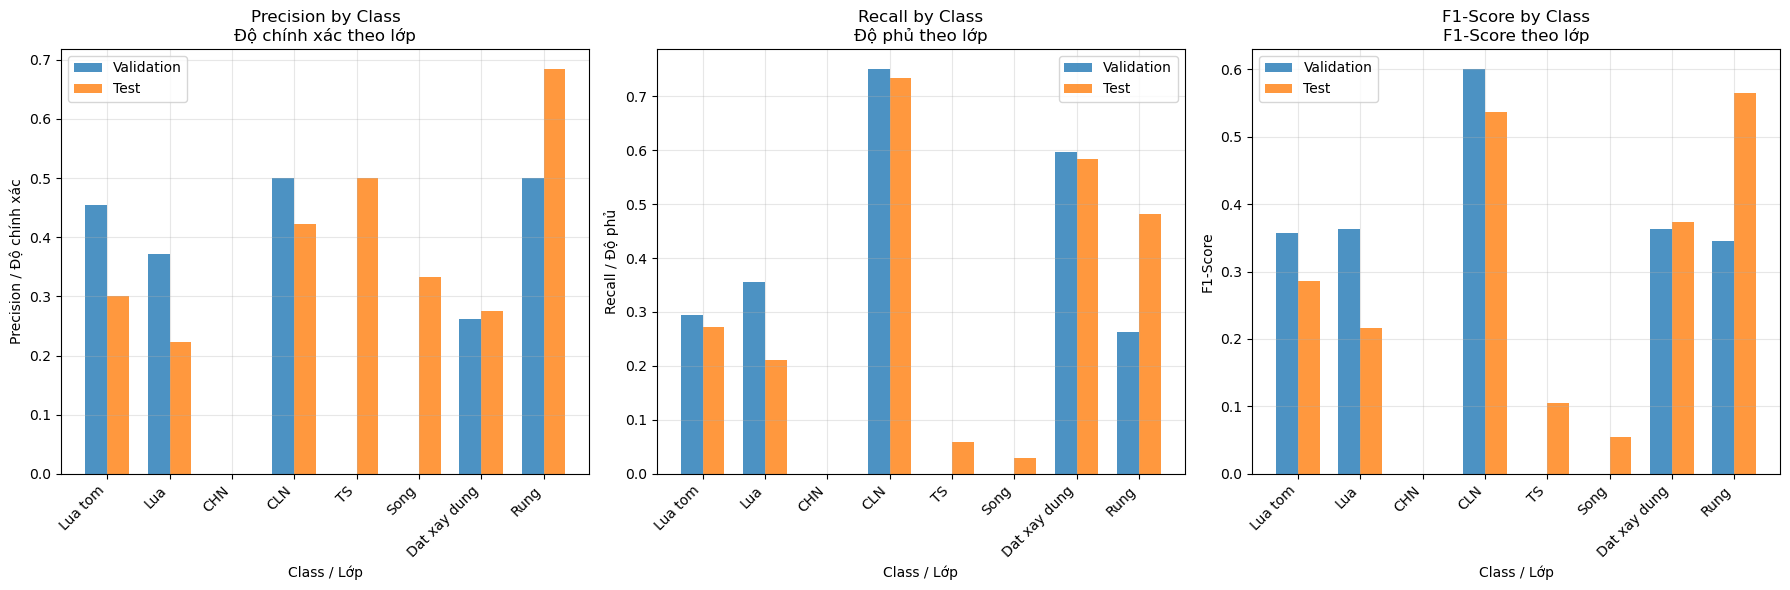


Detailed Metrics Table / Bảng metrics chi tiết:
       Class  Precision (Val)  Recall (Val)  F1-Score (Val)  Precision (Test)  Recall (Test)  F1-Score (Test)
     Lua tom         0.454545      0.294118        0.357143          0.300000       0.272727         0.285714
         Lua         0.372093      0.355556        0.363636          0.222222       0.210526         0.216216
         CHN         0.000000      0.000000        0.000000          0.000000       0.000000         0.000000
         CLN         0.500000      0.750000        0.600000          0.423077       0.733333         0.536585
          TS         0.000000      0.000000        0.000000          0.500000       0.058824         0.105263
        Song         0.000000      0.000000        0.000000          0.333333       0.029412         0.054054
Dat xay dung         0.261682      0.595745        0.363636          0.274510       0.583333         0.373333
        Rung         0.500000      0.263158        0.344828          0.

In [30]:
class_names = ['Lua tom', 'Lua', 'CHN', 'CLN', 'TS', 'Song', 'Dat xay dung', 'Rung']
# Tính độ chính xác theo từng lớp
from sklearn.metrics import precision_recall_fscore_support

precision_val, recall_val, f1_val, _ = precision_recall_fscore_support(y_val, y_pred, average=None)
precision_test, recall_test, f1_test, _ = precision_recall_fscore_support(y_test, y_pred_test, average=None)

# Tạo DataFrame để dễ visualize
metrics_df = pd.DataFrame({
    'Class': class_names,
    'Precision (Val)': precision_val,
    'Recall (Val)': recall_val,
    'F1-Score (Val)': f1_val,
    'Precision (Test)': precision_test,
    'Recall (Test)': recall_test,
    'F1-Score (Test)': f1_test
})

# Vẽ biểu đồ so sánh các metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

x = np.arange(len(class_names))
width = 0.35

# Precision
axes[0].bar(x - width/2, precision_val, width, label='Validation', alpha=0.8)
axes[0].bar(x + width/2, precision_test, width, label='Test', alpha=0.8)
axes[0].set_xlabel('Class / Lớp')
axes[0].set_ylabel('Precision / Độ chính xác')
axes[0].set_title('Precision by Class\nĐộ chính xác theo lớp')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Recall
axes[1].bar(x - width/2, recall_val, width, label='Validation', alpha=0.8)
axes[1].bar(x + width/2, recall_test, width, label='Test', alpha=0.8)
axes[1].set_xlabel('Class / Lớp')
axes[1].set_ylabel('Recall / Độ phủ')
axes[1].set_title('Recall by Class\nĐộ phủ theo lớp')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1-Score
axes[2].bar(x - width/2, f1_val, width, label='Validation', alpha=0.8)
axes[2].bar(x + width/2, f1_test, width, label='Test', alpha=0.8)
axes[2].set_xlabel('Class / Lớp')
axes[2].set_ylabel('F1-Score')
axes[2].set_title('F1-Score by Class\nF1-Score theo lớp')
axes[2].set_xticks(x)
axes[2].set_xticklabels(class_names, rotation=45, ha='right')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Hiển thị bảng metrics
print("\nDetailed Metrics Table / Bảng metrics chi tiết:")
print(metrics_df.to_string(index=False))

In [31]:
# Lấy mô hình Random Forest tốt nhất từ pipeline
best_rf_model = grid_search.best_estimator_.named_steps['classifier']

# Lấy feature importances
feature_importances = best_rf_model.feature_importances_

# Dynamic feature names based on actual number of features
n_features = len(feature_importances)
if n_features >= 2:
    feature_names = [f'NDVI_Step_{i+1}' for i in range(n_features - 2)] + ['VH (Sentinel-1)', 'VV (Sentinel-1)']
else:
    feature_names = [f'Feature_{i+1}' for i in range(n_features)]

# Tạo DataFrame và sắp xếp theo importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Feature Importance Ranking / Xếp hạng mức độ quan trọng của đặc trưng:")
print("="*70)
for idx, row in importance_df.iterrows():
    print(f"{row['Feature']:25s}: {row['Importance']:.4f} ({row['Importance']*100:.2f}%)")
print("="*70)
for idx, row in importance_df.iterrows():
    print(f"{row['Feature']:25s}: {row['Importance']:.4f} ({row['Importance']*100:.2f}%)")
print("="*70)

Feature Importance Ranking / Xếp hạng mức độ quan trọng của đặc trưng:
NDVI_Step_1              : 0.2464 (24.64%)
NDVI_Step_13             : 0.0461 (4.61%)
NDVI_Step_22             : 0.0391 (3.91%)
NDVI_Step_4              : 0.0381 (3.81%)
NDVI_Step_14             : 0.0375 (3.75%)
NDVI_Step_17             : 0.0365 (3.65%)
NDVI_Step_21             : 0.0324 (3.24%)
NDVI_Step_18             : 0.0323 (3.23%)
NDVI_Step_25             : 0.0316 (3.16%)
VV (Sentinel-1)          : 0.0313 (3.13%)
NDVI_Step_2              : 0.0311 (3.11%)
NDVI_Step_5              : 0.0310 (3.10%)
VH (Sentinel-1)          : 0.0304 (3.04%)
NDVI_Step_19             : 0.0299 (2.99%)
NDVI_Step_23             : 0.0298 (2.98%)
NDVI_Step_24             : 0.0287 (2.87%)
NDVI_Step_3              : 0.0281 (2.81%)
NDVI_Step_6              : 0.0281 (2.81%)
NDVI_Step_7              : 0.0261 (2.61%)
NDVI_Step_15             : 0.0236 (2.36%)
NDVI_Step_12             : 0.0236 (2.36%)
NDVI_Step_8              : 0.0230 (2.30%)
NDVI

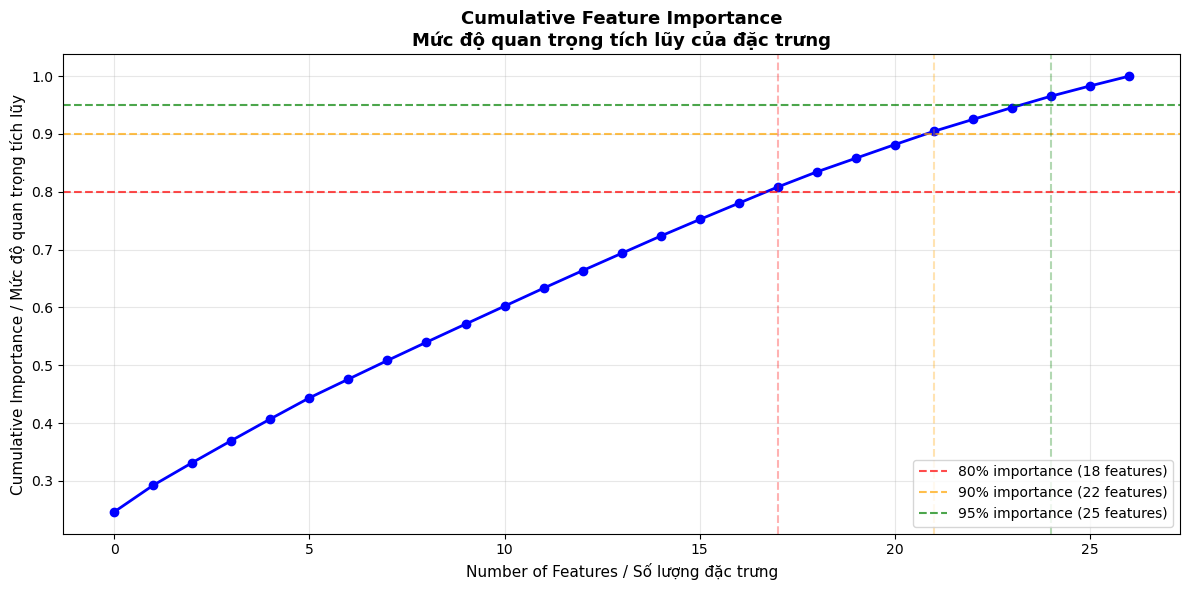


CUMULATIVE IMPORTANCE ANALYSIS / PHÂN TÍCH TÍCH LŨY
Features needed for 80% importance: 18/27 (66.7%)
Features needed for 90% importance: 22/27 (81.5%)
Features needed for 95% importance: 25/27 (92.6%)


In [32]:
# Biểu đồ cumulative importance (tích lũy)
importance_sorted = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
cumulative_importance = np.cumsum(importance_sorted['Importance'])

plt.figure(figsize=(12, 6))
plt.plot(range(len(cumulative_importance)), cumulative_importance, 'b-o', linewidth=2, markersize=6)

# Thêm đường ngang tại 80%, 90%, 95%
thresholds = [0.8, 0.9, 0.95]
colors_thresh = ['red', 'orange', 'green']
for thresh, color in zip(thresholds, colors_thresh):
    n_features_needed = np.argmax(cumulative_importance >= thresh) + 1
    plt.axhline(y=thresh, color=color, linestyle='--', alpha=0.7, 
                label=f'{thresh*100:.0f}% importance ({n_features_needed} features)')
    plt.axvline(x=n_features_needed-1, color=color, linestyle='--', alpha=0.3)

plt.xlabel('Number of Features / Số lượng đặc trưng', fontsize=11)
plt.ylabel('Cumulative Importance / Mức độ quan trọng tích lũy', fontsize=11)
plt.title('Cumulative Feature Importance\nMức độ quan trọng tích lũy của đặc trưng', 
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# In thống kê
print("\n" + "="*70)
print("CUMULATIVE IMPORTANCE ANALYSIS / PHÂN TÍCH TÍCH LŨY")
print("="*70)
for thresh in thresholds:
    n_features = np.argmax(cumulative_importance >= thresh) + 1
    print(f"Features needed for {thresh*100:.0f}% importance: {n_features}/{len(importance_df)} "
          f"({n_features/len(importance_df)*100:.1f}%)")
print("="*70)

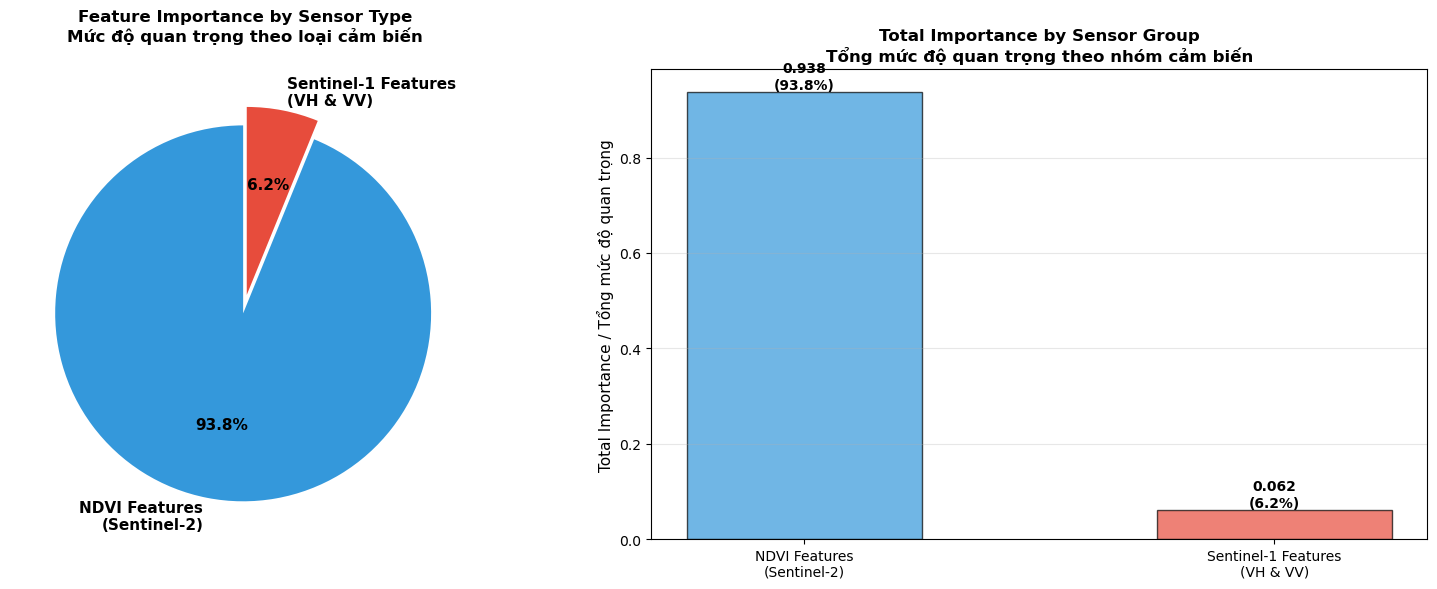


FEATURE GROUP SUMMARY / TỔNG KẾT THEO NHÓM ĐẶC TRƯNG
NDVI Features (Sentinel-2):      0.9384 (93.8%)
Sentinel-1 Features (VH & VV):   0.0616 (6.2%)
Total:                           1.0000 (100.0%)


In [33]:
# Biểu đồ phân nhóm: NDVI vs Sentinel-1 importance
# Tính tổng importance cho từng nhóm
total_importance = importance_df['Importance'].sum()

# Tách NDVI features và Sentinel-1 features
ndvi_features = importance_df[importance_df['Feature'].str.contains('NDVI', case=False)]
sentinel1_features = importance_df[importance_df['Feature'].str.contains('VH|VV', case=False, regex=True)]

ndvi_importance = ndvi_features['Importance'].sum()
sentinel1_importance = sentinel1_features['Importance'].sum()

# Vẽ biểu đồ tròn (Pie chart)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ tròn: So sánh NDVI vs Sentinel-1
categories = ['NDVI Features\n(Sentinel-2)', 'Sentinel-1 Features\n(VH & VV)']
importances = [ndvi_importance, sentinel1_importance]
colors_pie = ['#3498db', '#e74c3c']
explode = (0.05, 0.05)

if sum(importances) > 0:
    wedges, texts, autotexts = axes[0].pie(importances, labels=categories, autopct='%1.1f%%',
                                            colors=colors_pie, explode=explode, startangle=90,
                                            textprops={'fontsize': 11, 'weight': 'bold'})
else:
    axes[0].text(0.5, 0.5, 'No Feature Names Matched', ha='center', va='center')
axes[0].set_title('Feature Importance by Sensor Type\nMức độ quan trọng theo loại cảm biến', 
                  fontsize=12, fontweight='bold', pad=20)

# Biểu đồ cột: Tổng hợp theo nhóm
axes[1].bar(categories, importances, color=colors_pie, alpha=0.7, edgecolor='black', width=0.5)
axes[1].set_ylabel('Total Importance / Tổng mức độ quan trọng', fontsize=11)
axes[1].set_title('Total Importance by Sensor Group\nTổng mức độ quan trọng theo nhóm cảm biến', 
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Thêm giá trị lên cột
for i, (cat, imp) in enumerate(zip(categories, importances)):
    axes[1].text(i, imp, f'{imp:.3f}\n({imp/total_importance*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("FEATURE GROUP SUMMARY / TỔNG KẾT THEO NHÓM ĐẶC TRƯNG")
print("="*70)
print(f"NDVI Features (Sentinel-2):      {ndvi_importance:.4f} ({ndvi_importance/total_importance*100:.1f}%)")
print(f"Sentinel-1 Features (VH & VV):   {sentinel1_importance:.4f} ({sentinel1_importance/total_importance*100:.1f}%)")
print(f"Total:                           {total_importance:.4f} (100.0%)")
print("="*70)

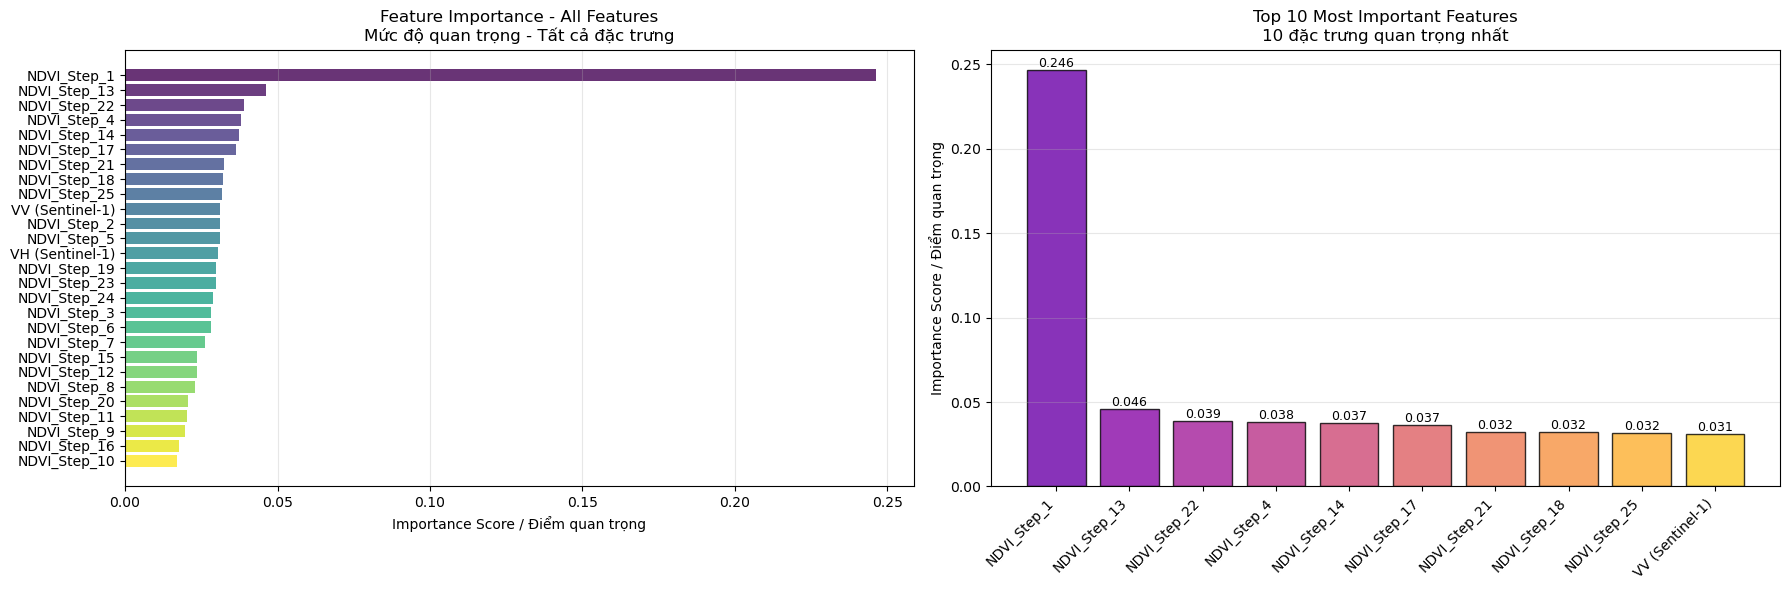

In [34]:
# Vẽ biểu đồ Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ 1: Tất cả features (horizontal bar chart)
colors = plt.cm.viridis(np.linspace(0, 1, len(importance_df)))
axes[0].barh(range(len(importance_df)), importance_df['Importance'], color=colors, alpha=0.8)
axes[0].set_yticks(range(len(importance_df)))
axes[0].set_yticklabels(importance_df['Feature'])
axes[0].set_xlabel('Importance Score / Điểm quan trọng')
axes[0].set_title('Feature Importance - All Features\nMức độ quan trọng - Tất cả đặc trưng')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()

# Biểu đồ 2: Top 10 features quan trọng nhất
top_n = min(10, len(importance_df))
top_importance = importance_df.head(top_n)
colors_top = plt.cm.plasma(np.linspace(0.2, 0.9, top_n))

bars = axes[1].bar(range(top_n), top_importance['Importance'], color=colors_top, alpha=0.8, edgecolor='black')
axes[1].set_xticks(range(top_n))
axes[1].set_xticklabels(top_importance['Feature'], rotation=45, ha='right')
axes[1].set_ylabel('Importance Score / Điểm quan trọng')
axes[1].set_title(f'Top {top_n} Most Important Features\n{top_n} đặc trưng quan trọng nhất')
axes[1].grid(True, alpha=0.3, axis='y')

# Thêm giá trị lên từng cột
for bar, imp in zip(bars, top_importance['Importance']):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{imp:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Note:** The `importance_df` DataFrame is calculated in the cell above under section 7. Run that cell first before running the visualization cells below.

**Lưu ý:** DataFrame `importance_df` được tính toán ở ô phía trên trong mục 7. Chạy ô đó trước khi chạy các ô vẽ biểu đồ bên dưới.

#### 7. Feature Importance / Mức độ quan trọng của đặc trưng

#### 5. Per-Class Accuracy / Độ chính xác theo từng lớp

In [35]:
class_names = ['Lua tom', 'Lua', 'CHN', 'CLN', 'TS', 'Song', 'Dat xay dung', 'Rung']
# Classification report chi tiết
print("="*60)
print("VALIDATION SET - TẬP VALIDATION")
print("="*60)
print(classification_report(y_val, y_pred, target_names=class_names))

print("\n" + "="*60)
print("TEST SET - TẬP TEST")
print("="*60)
print(classification_report(y_test, y_pred_test, target_names=class_names))

VALIDATION SET - TẬP VALIDATION
              precision    recall  f1-score   support

     Lua tom       0.45      0.29      0.36        17
         Lua       0.37      0.36      0.36        45
         CHN       0.00      0.00      0.00        11
         CLN       0.50      0.75      0.60        32
          TS       0.00      0.00      0.00        29
        Song       0.00      0.00      0.00        26
Dat xay dung       0.26      0.60      0.36        47
        Rung       0.50      0.26      0.34        19

    accuracy                           0.35       226
   macro avg       0.26      0.28      0.25       226
weighted avg       0.28      0.35      0.29       226


TEST SET - TẬP TEST
              precision    recall  f1-score   support

     Lua tom       0.30      0.27      0.29        11
         Lua       0.22      0.21      0.22        38
         CHN       0.00      0.00      0.00         4
         CLN       0.42      0.73      0.54        30
          TS       0.50  

/home/x79/miniconda3/envs/env_01/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/x79/miniconda3/envs/env_01/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/x79/miniconda3/envs/env_01/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

#### 4. Classification Report / Báo cáo phân loại chi tiết

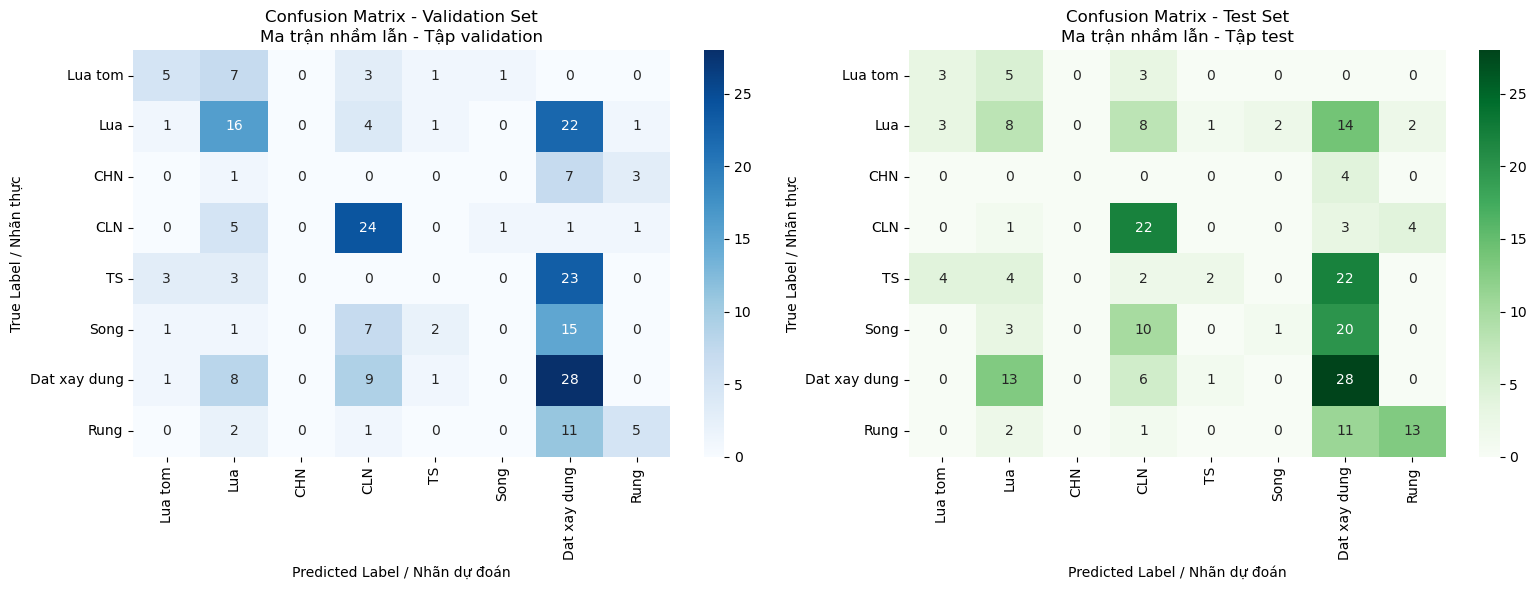

In [36]:
class_names = ['Lua tom', 'Lua', 'CHN', 'CLN', 'TS', 'Song', 'Dat xay dung', 'Rung']
# Confusion Matrix cho tập validation và test
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Validation confusion matrix
cm_val = confusion_matrix(y_val, y_pred)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix - Validation Set\nMa trận nhầm lẫn - Tập validation')
axes[0].set_ylabel('True Label / Nhãn thực')
axes[0].set_xlabel('Predicted Label / Nhãn dự đoán')

# Test confusion matrix
cm_test = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix - Test Set\nMa trận nhầm lẫn - Tập test')
axes[1].set_ylabel('True Label / Nhãn thực')
axes[1].set_xlabel('Predicted Label / Nhãn dự đoán')

plt.tight_layout()
plt.show()

#### 3. Confusion Matrix / Ma trận nhầm lẫn

/home/x79/miniconda3/envs/env_01/lib/python3.10/site-packages/cuml/ensemble/randomforestclassifier.py:247: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  return self._fit_forest(X_m, y_m)
/home/x79/miniconda3/envs/env_01/lib/python3.10/site-packages/cuml/ensemble/randomforestclassifier.py:247: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  return self._fit_forest(X_m, y_m)
/home/x79/miniconda3/envs/env_01/lib/python3.10/site-packages/cuml/ensemble/randomforestclassifier.py:247: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  return self._fit_forest(X_m, y_m)
/home/x79/miniconda3/envs/env_01/lib/python3.10/site-packages/cuml/ensemble/randomforestclassifier.py:247: UserWarning: The num

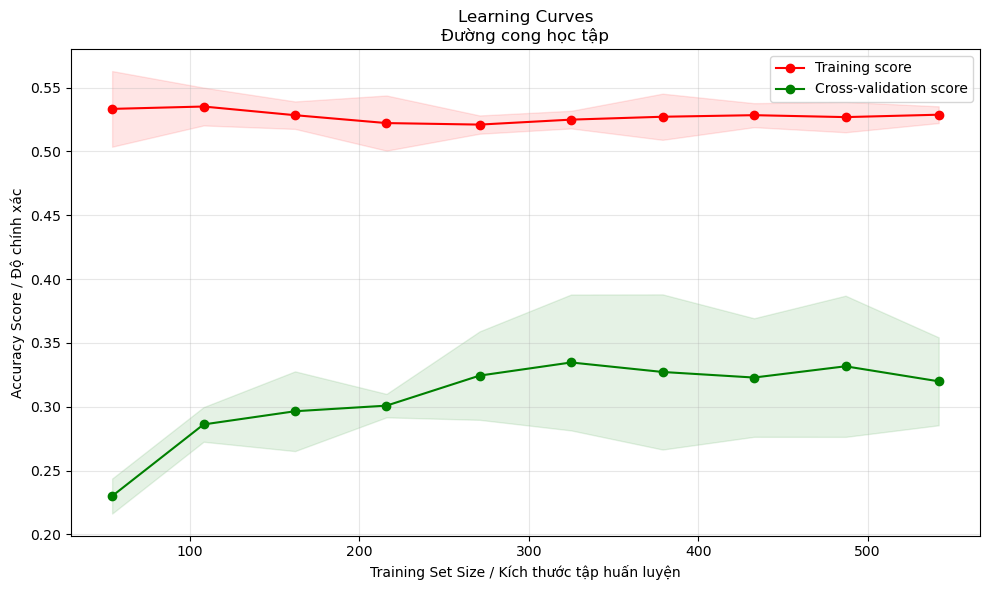

In [37]:
# Vẽ learning curves để thấy hiệu suất qua các kích thước tập train khác nhau
train_sizes, train_scores, val_scores = learning_curve(
    grid_search.best_estimator_, 
    X_train, 
    y_train, 
    cv=5, 
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, val_mean, 'o-', color='g', label='Cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='g')

plt.xlabel('Training Set Size / Kích thước tập huấn luyện')
plt.ylabel('Accuracy Score / Độ chính xác')
plt.title('Learning Curves\nĐường cong học tập')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Learning Curves / Đường cong học tập

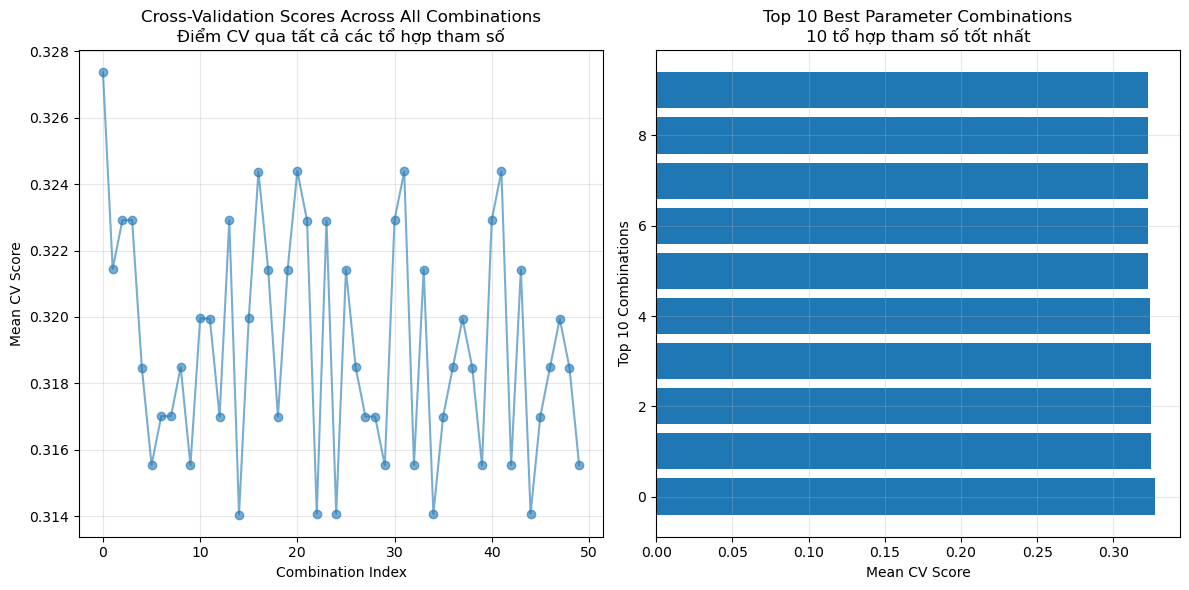

Best CV Score: 0.3274
Điểm CV tốt nhất: 0.3274


In [38]:
# Vẽ biểu đồ kết quả Cross-Validation từ GridSearchCV
cv_results = pd.DataFrame(grid_search.cv_results_)

# Lấy top 10 kết quả tốt nhất
top_results = cv_results.nlargest(10, 'mean_test_score')

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(cv_results['mean_test_score'], marker='o', linestyle='-', alpha=0.6)
plt.xlabel('Combination Index')
plt.ylabel('Mean CV Score')
plt.title('Cross-Validation Scores Across All Combinations\nĐiểm CV qua tất cả các tổ hợp tham số')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.barh(range(len(top_results)), top_results['mean_test_score'].values)
plt.xlabel('Mean CV Score')
plt.ylabel('Top 10 Combinations')
plt.title('Top 10 Best Parameter Combinations\n10 tổ hợp tham số tốt nhất')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best CV Score: {grid_search.best_score_:.4f}")
print(f"Điểm CV tốt nhất: {grid_search.best_score_:.4f}")

#### 1. Cross-Validation Scores / Điểm số xác thực chéo

In [39]:
# Định nghĩa tên các lớp / Define class names
class_names = ['Lua tom', 'Lua', 'CHN', 'CLN', 'TS', 'Song', 'Dat xay dung', 'Rung']
print(f"Defined {len(class_names)} classes: {', '.join(class_names)}")

Defined 8 classes: Lua tom, Lua, CHN, CLN, TS, Song, Dat xay dung, Rung


### Model Performance Visualization / Trực quan hóa hiệu suất mô hình

### Save train model/ Lưu trữ mô hình huấn luyện

In [40]:
dir_save_model = "model_train"
if not os.path.exists(dir_save_model):
    os.mkdir(dir_save_model)
joblib.dump(grid_search, os.path.join(dir_save_model, "model.joblib"))

['model_train/model.joblib']

In [41]:
client.close()
cluster.close()